# XOPT - INTERPRETABLE METAHEURISTICS FOR COMBINATORIAL OPTIMIZATION

## CO-OCCURRENCE GRAPH ANALYSIS (TOP 5% LTM)

This notebook replicates the original co-occurrence analysis, but restricts every experiment to the top 5% best solutions stored in the long-term memory, ranked by cost.


### SETTING THE ENVIRONMENT

Importing the libraries:

In [1]:
import sys

from pathlib import Path

parent_path = Path().resolve().parent.parent

if str(parent_path) not in sys.path:
    sys.path.insert(0, str(parent_path))

In [2]:
import pymedian

import numpy    as np
import networkx as nx
import seaborn  as sns
import matplotlib.pyplot as plt

from networkx.algorithms import community, betweenness_centrality

This cell locates the "instances" folder in the project root and counts how many p-median instance files exist:

In [3]:
ROOT          = Path.cwd().resolve().parent.parent
INSTANCES_DIR = ROOT / "instances"

if not INSTANCES_DIR.exists():
    raise FileNotFoundError(f"Instances folder not found: {INSTANCES_DIR}")

print(f"Total number of p-median instances: {len(list(INSTANCES_DIR.glob('pmed[0-9]*.txt')))}")

Total number of p-median instances: 40


### APPLYING

We selected a few classic p-median instances and recorded the results obtained:

In [4]:
instance      = "pmed11.txt"
instance_path = str(INSTANCES_DIR / instance)

summary, details = pymedian.solve_pmedian(instance_path,
                                          restarts=8   ,
                                          max_iter=25  ,
                                          factor  =2   )

best_facilities  = [
    idx - 1
    for idx in summary["tspmed_facilities"]
]
long_term_memory = details["long_term_memory"]

if not long_term_memory:
    raise ValueError("Long term memory is empty!")


print(f"Instance {summary['instance'][:-4]} ({summary['p']}-{summary['n']})")

print()
print(f"  K-Medoids ({summary['kmedoids_cost']}): {summary['medoids'          ][:10]}")
print(f"  TSPMED    ({summary['tspmed_cost'  ]}): {summary['tspmed_facilities'][:10]}")

print()
print(f"Obs.: Distinct solutions recorded in long term memory is {summary['long_term_mem']}!")

Instance /home/rei-luisinho/xopt/instances/pmed11 (5-300)

  K-Medoids (7696.0): [98, 201, 167, 24, 31]
  TSPMED    (7696.0): [98, 201, 167, 24, 31]

Obs.: Distinct solutions recorded in long term memory is 835!


In [5]:
TOP_FRACTION = 0.05


top_solution_count = max(
    1, int(np.ceil(len(long_term_memory) * TOP_FRACTION))
)


analysis_long_term_memory = sorted(
    long_term_memory,
    key=lambda sol: sol["cost"]
)[:top_solution_count]

analysis_costs = np.array(
    [
        sol["cost"]
        for sol in analysis_long_term_memory
    ],
    dtype=float
)

analysis_cost_cutoff = float(analysis_costs.max())


print(f"Obs.: Analysis restricted to the top {TOP_FRACTION}% best long-term memory solutions!"    )
print(f"      Remaining {top_solution_count} solutions, with {analysis_cost_cutoff:.1f} max cost.")

Obs.: Analysis restricted to the top 0.05% best long-term memory solutions!
      Remaining 42 solutions, with 7740.0 max cost.


### FACILITY CO-OCCURRENCE NETWORK (TOP 5% BEST)

To better understand the structural patterns emerging from the **top 5% best solutions** stored in long-term memory, we construct a **facility co-occurrence adjacency matrix**. Each entry $(i, j)$ represents how many times facilities *i* and *j* were simultaneously selected across this filtered solution set. This allows us to:

- Identify **strong facility pairings** that frequently appear together  
- Detect potential **structural dependencies or complementarities**  
- Reveal clusters of facilities that characterize the **elite region** of the solution space  
- Provide a more interpretable view of the solution landscape beyond individual optimal solutions  

The resulting heatmap offers a visual representation of the collective behavior of facilities across the filtered near-optimal solution set.


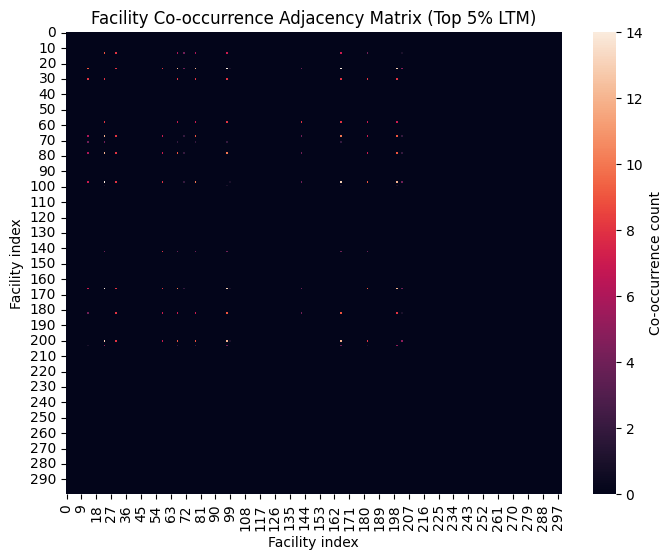

In [6]:
matrix = np.vstack(
    [
        np.array(sol["facilities"])
        for sol in analysis_long_term_memory
    ]
)
costs  = analysis_costs.copy()

adjacency_matrix = np.zeros(
    (
        summary['n'],
        summary['n']
    ),
    dtype=int
)

for sol in analysis_long_term_memory:
    facilities       = np.array(sol["facilities"])
    facility_indices = np.where(facilities  ==  1)[0]

    for i in range(len(facility_indices)):
        for j in range(i + 1, len(facility_indices)):
            idx_i = facility_indices[i]
            idx_j = facility_indices[j]

            adjacency_matrix[idx_i, idx_j] += 1
            adjacency_matrix[idx_j, idx_i] += 1


plt.figure(figsize=(8, 6))

sns.heatmap(
    adjacency_matrix, cbar_kws={'label': 'Co-occurrence count'}
)

plt.title ("Facility Co-occurrence Adjacency Matrix (Top 5% LTM)")
plt.xlabel("Facility index")
plt.ylabel("Facility index")

plt.show()

### GREEDY MODULARITY COMMUNITY DETECTION

In this step, we convert the **facility co-occurrence adjacency matrix** into a **weighted, undirected graph**:

- Each **node** represents a facility (indexed from `0` to `n-1`);
- An **edge** between facilities *(i, j)* exists if they co-occur in at least one solution;
- The edge **weight** equals the number of co-occurrences, so stronger links correspond to pairs that appear together more frequently.

We then apply **greedy modularity community detection** (Clauset–Newman–Moore) to partition the graph into **communities**. Each community is a group of facilities that tends to co-occur more **within the group** than with facilities outside the group.

For each detected community, we report:

- The number of facilities in the group;
- A short list of facility indices;
- The **average internal co-occurrence strength** (mean edge weight among connected facility pairs inside the community).

These communities can be interpreted as **recurring facility modules** that characterize different near-optimal regions of the solution space.

In [7]:
G = nx.Graph()

G.add_nodes_from(range(summary['n']))

for i in range(summary['n']):
    for j in range(i + 1, summary['n']):
        if adjacency_matrix[i, j] > 0:
            G.add_edge(i, j, weight=adjacency_matrix[i, j])


communities = list(community.greedy_modularity_communities(G))

print(f"Greedy modularity found {len(communities)} communities!")

Greedy modularity found 289 communities!


In [8]:
best_set = set(best_facilities)

filtered = []

for idx, comm in enumerate(communities):
    if len(comm) <= 1:
        continue

    facilities_in_comm = sorted(list(comm))
    best_in_comm       = sorted(list(best_set.intersection(comm)))

    avg_cooccurrence = np.mean([
        adjacency_matrix[i, j]
        for i in facilities_in_comm
        for j in facilities_in_comm
        if i < j and adjacency_matrix[i, j] > 0
    ])

    filtered.append(
        (
            idx               ,
            facilities_in_comm,
            best_in_comm      ,
            avg_cooccurrence  ,
        )
    )

print(f"Communities shown (size > 1): {len(filtered)}")
print()

for idx, size, best_in_comm, cooccurrence in filtered:
    best_show = ", ".join(map(str, best_in_comm))

    print(f"Community {idx}:"      )
    print(f"{len(size)} facilities")
    print(f"  Avg co-occurrence of {cooccurrence:.2f}"       )
    print(f"  Best facilities in this community: {best_show}")

    print()


best_facilities_sorted = sorted(best_set)


print("*** Best solution ***")
print(f"  Count: {len(best_facilities_sorted)}")
print(f"  Facilities: {', '.join(map(str, best_facilities_sorted))}")

Communities shown (size > 1): 3

Community 0:
5 facilities
  Avg co-occurrence of 5.89
  Best facilities in this community: 30

Community 1:
5 facilities
  Avg co-occurrence of 6.22
  Best facilities in this community: 23, 166, 200

Community 2:
4 facilities
  Avg co-occurrence of 6.67
  Best facilities in this community: 97

*** Best solution ***
  Count: 5
  Facilities: 23, 30, 97, 166, 200


### ANTI-COMMUNITIES (MAX-p-CUT)

In this analysis, we seek a **multipartite structure**: groups with **low internal connectivity** and **high external connectivity**. This objective is naturally formulated as a **Max-p-Cut (Max-k-Cut)** problem, which partitions the nodes into `p` groups to **maximize the total weight of edges between groups**. Since the total edge weight of the graph is fixed, maximizing the cut is equivalent to minimizing the total weight of edges within groups.

In [9]:
p = 5

n_restarts = 30
max_iter   = 2000
seed       = 42


A = np.asarray(
    adjacency_matrix, dtype=float
).copy()

n = A.shape[0]

In [10]:
def _random_labels(n, p, rng):
    labels = rng.integers(0, p, size=n)

    if n >= p:
        perm             = rng.permutation(n)
        labels[perm[:p]] = np .arange(p)

    return labels

def _group_sums(A, labels, p):
    n = A.shape[0]

    sums = np.zeros(
        (n, p), dtype=float
    )

    for g in range(p):
        members = labels == g

        if np.any(members):
            sums[:, g] = A[:, members].sum(axis=1)

    return sums


def partition_weights(labels, A):
    same = labels[:, None] == labels[None, :]

    internal = float(np.triu(A * same, 1).sum())
    total    = float(np.triu(A, 1).sum())

    cut = total - internal

    return cut, internal


def max_p_cut_local_search(
    A,
    p,
    n_restarts=20  ,
    max_iter  =2000,
    seed      =42
):
    A = np.asarray(A, dtype=float)

    n = A.shape[0]
    p = int(p)

    if p > n:
        p = n

    n_restarts = max(1, int(n_restarts))
    max_iter   = max(1, int(max_iter  ))

    total_weight = float(np.triu(A, 1).sum() )
    rng          = np.random.default_rng(seed)

    best_cut      = -np.inf
    best_internal =  np.inf
    best_labels   = None

    for _ in range(n_restarts):
        labels = _random_labels(n, p     , rng)
        sums   = _group_sums   (A, labels, p  )

        internal = float(
            np.triu(
                A * (labels[:, None] == labels[None, :]), 1
            ).sum()
        )
        cut      = total_weight - internal

        for _ in range(max_iter):
            improved = False

            for node in rng.permutation(n):
                old_group = labels[node]

                gains            = sums[node, old_group] - sums[node, :]
                gains[old_group] = -np.inf

                new_group = int  (np.argmax(gains))
                gain      = float(gains[new_group])

                if gain > 1e-12:
                    labels[node] = new_group

                    cut += gain

                    sums[:, old_group] -= A[:, node]
                    sums[:, new_group] += A[:, node]

                    improved = True

            if not improved:
                break

        internal = total_weight - cut

        if cut > best_cut + 1e-12:
            best_cut      = float(cut     )
            best_internal = float(internal)
            best_labels = labels.copy()

    return best_labels, best_cut, best_internal


def internal_density(labels, A):
    labels = np.asarray(labels)

    _, internal = partition_weights(labels, A)

    p_eff = int(labels.max()) + 1
    sizes = np.bincount(labels, minlength=p_eff)

    possible = float(
        np.sum(sizes * (sizes - 1) / 2.0)
    )

    if possible <= 0:
        return 0.0

    return internal / possible


def external_density(labels, A):
    labels = np.asarray(labels)

    cut, _ = partition_weights(labels, A)

    n           = len(labels)
    total_pairs = float(n * (n - 1) / 2.0)

    p_eff = int(labels.max()) + 1
    sizes = np.bincount(labels, minlength=p_eff)

    internal_pairs = float(np.sum(sizes * (sizes - 1) / 2.0))
    external_pairs = total_pairs - internal_pairs

    if external_pairs <= 0:
        return 0.0

    return cut / external_pairs


def cluster_delta_stats(labels, A, p):
    labels = np.asarray(labels)

    rows = []

    for g in range(p):
        members = np.where(labels == g)[0]
        size    = int(members.size)

        if size == 0:
            rows.append(
                {
                    'cluster'   : g,
                    'size'      : 0,
                    'delta_in'  : 0.0,
                    'delta_out' : 0.0,
                    'score'     : 0.0,
                }
            )

            continue

        inside  = A[np.ix_(members, members    )]
        outside = A[np.ix_(members, labels != g)]

        internal_weight = float(inside .sum() / 2.0)
        external_weight = float(outside.sum())

        delta_in  = (2.0 * internal_weight) / size
        delta_out = external_weight         / size

        score = delta_out / (delta_in + 1e-9)

        rows.append(
            {
                'cluster'   : g   ,
                'size'      : size,
                'delta_in'  : float(delta_in ),
                'delta_out' : float(delta_out),
                'score'     : float(score    ),
            }
        )

    return rows

In [11]:
labels, cut_weight, internal_weight = max_p_cut_local_search(
    A,
    p,
    n_restarts=n_restarts,
    max_iter  =max_iter  ,
    seed      =seed      ,
)

fraction_cut  = cut_weight / (cut_weight + internal_weight + 1e-12)
cluster_sizes = np.bincount(labels, minlength=p)


print(f"=== Max-p-Cut Local Search (p = {p}) ===")
print()

print(f"Fraction cut     = {fraction_cut*100:.2f}%")
print(f"Internal density = {internal_density(labels, A)*100:.2f}%")
print(f"External density = {external_density(labels, A)*100:.2f}%")

print()
print("Cluster sizes:")
for c in range(p):
    print(f"  Cluster {c}: {int(cluster_sizes[c])} nodes")

=== Max-p-Cut Local Search (p = 5) ===

Fraction cut     = 100.00%
Internal density = 0.00%
External density = 1.17%

Cluster sizes:
  Cluster 0: 55 nodes
  Cluster 1: 64 nodes
  Cluster 2: 56 nodes
  Cluster 3: 64 nodes
  Cluster 4: 61 nodes


In [12]:
print("Best facilities clusters:")

for f in sorted(best_facilities):
    print(f"  Facility {f:3d} -> Cluster {int(labels[f])}")

Best facilities clusters:
  Facility  23 -> Cluster 3
  Facility  30 -> Cluster 0
  Facility  97 -> Cluster 2
  Facility 166 -> Cluster 1
  Facility 200 -> Cluster 4


### K-CORE DECOMPOSITION

In this section, we analyze the structural hierarchy of the facility co-occurrence network using **k-core decomposition**. K-core decomposition reveals the **nested core-periphery structure** of the network. A facility belongs to the *k-core* if it is connected to at least *k* other facilities that are themselves similarly well-connected.

This allows us to:

- Identify **structurally central facilities** within the solution landscape;
- Distinguish between **core and peripheral nodes**;
- Assess whether the best solution lies in the **deep structural nucleus** of the co-occurrence graph;
- Reveal hierarchical robustness patterns in the network.

Higher k-core values indicate facilities embedded in dense, mutually connected regions of the solution space, suggesting structural importance across near-optimal solutions.

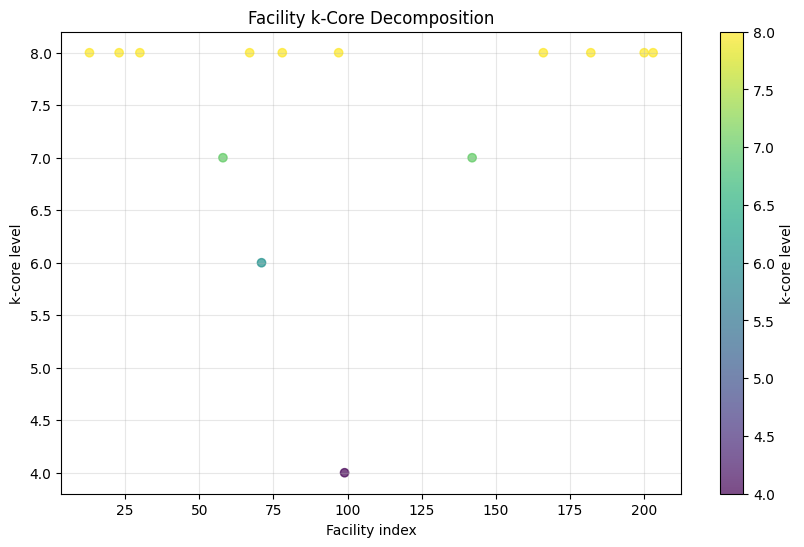

In [13]:
G_binary = nx.Graph()

G_binary.add_nodes_from(range(summary['n']))

for i in range(summary['n']):
    for j in range(i + 1, summary['n']):
        if adjacency_matrix[i, j] > 0:
            G_binary.add_edge(i, j)

k_cores       = nx.core_number(G_binary)
k_core_values = np.array(
    [
        k_cores[i]
        for i in range(summary['n'])
    ]
)

mask = k_core_values >= 2

filtered_indices  = np.arange(summary['n'])[mask]
filtered_k_values = k_core_values          [mask]


plt.figure(figsize=(10, 6))

plt.scatter(
    filtered_indices       ,
    filtered_k_values      ,
    c    =filtered_k_values,
    cmap ='viridis',
    alpha=0.7      ,
)

plt.xlabel("Facility index")
plt.ylabel("k-core level"  )
plt.title ("Facility k-Core Decomposition")

plt.colorbar(label='k-core level')
plt.grid    (True, alpha=0.3)

plt.show()

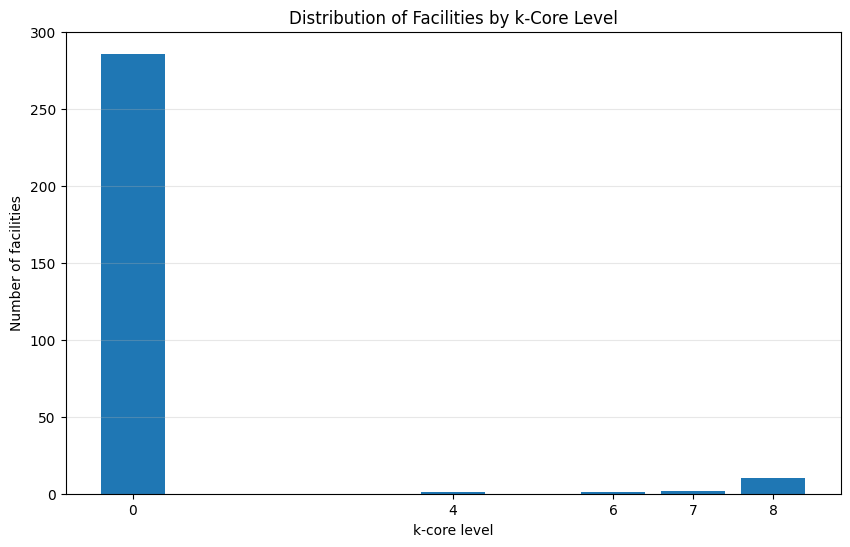

In [14]:
core_levels = sorted(set(k_cores.values()))

counts = [
    list(
        k_cores.values()
    ).count(k)
    for k in core_levels
]


plt.figure(figsize=(10, 6))

plt.bar(core_levels, counts)

plt.xlabel("k-core level"        )
plt.ylabel("Number of facilities")
plt.title ("Distribution of Facilities by k-Core Level")

plt.xticks(core_levels)
plt.grid  (axis='y', alpha=0.3)

plt.show()

In [15]:
print("K-Core Levels of Best Solution Facilities:")
print()

best_set = set(best_facilities)

best_by_core = {}

for f in best_set:
    k = k_cores[f]
    best_by_core.setdefault(k, []).append(f)

for k in sorted(best_by_core.keys()):
    facilities = sorted(best_by_core[k])

    print(f"K-core {k}: {len(facilities)} best facilities")
    print(f"  Facilities: {', '.join(map(str, facilities))}")
    print()

K-Core Levels of Best Solution Facilities:

K-core 8: 5 best facilities
  Facilities: 23, 30, 97, 166, 200



In [16]:
print("Facilities in K-Core 8:")
print()

core_level = 8

facilities_in_core_8 = sorted(
    f for f, k in k_cores.items()
    if k == core_level
)

print(f"K-core {core_level}: {len(facilities_in_core_8)} facilities")
print(f"Facilities: {', '.join(map(str, facilities_in_core_8))}")

Facilities in K-Core 8:

K-core 8: 10 facilities
Facilities: 13, 23, 30, 67, 78, 97, 166, 182, 200, 203


### STRENGTH CENTRALITY

This code computes and analyzes the **strength centrality** of each facility in the co-occurrence network. In a weighted graph, the **strength** of a node is the sum of the weights of all edges connected to it. Here, edge weights represent how many times two facilities co-occur across the filtered top-5% solution set.

Mathematically:

$
\text{strength}(i) = \sum_j A_{ij}
$

Thus, a facility with high strength centrality:

- Frequently co-occurs with many other facilities;
- Is strongly embedded in the solution landscape;
- Plays a structurally influential role across the elite solutions.


In [17]:
strength_centrality = np.sum    (adjacency_matrix, axis=1)
sorted_indices      = np.argsort(strength_centrality)[::-1]


print("Top 15 facilities by strength centrality:")
print()

for rank, idx in enumerate(sorted_indices[:15], 1):
    star = "*" if idx in best_set else " "

    print(f"{rank:2d}. Facility {idx:3d}{star}: {strength_centrality[idx]:5.0f}")

Top 15 facilities by strength centrality:

 1. Facility  23*:   104
 2. Facility  97*:    92
 3. Facility 166*:    92
 4. Facility 200*:    84
 5. Facility  78 :    76
 6. Facility  67 :    76
 7. Facility 182 :    64
 8. Facility  30*:    64
 9. Facility  58 :    60
10. Facility  13 :    52
11. Facility 142 :    32
12. Facility 203 :    24
13. Facility  71 :    16
14. Facility  99 :     4
15. Facility  98 :     0


### BETWEENNESS CENTRALITY

This analysis computes the **betweenness centrality** of each facility in the co-occurrence graph. Betweenness centrality measures how frequently a facility lies on the shortest paths between other facilities. High values indicate **bridge nodes** that connect different structural regions of the network.

In the context of the solution landscape, facilities with high betweenness may:

- Connect distinct near-optimal modules;
- Act as structural transition elements;
- Play a strategic role in linking different solution patterns.

Unlike strength centrality (which measures interaction intensity) and k-core (which measures structural depth), betweenness captures the **global bridging role** of facilities within the network topology.

In [18]:
betweenness = betweenness_centrality(G, weight='weight')

betweenness_values = np.array(
    [
        betweenness[i]
        for i in range(summary['n'])
    ]
)

sorted_indices_betweenness = np.argsort(betweenness_values)[::-1]


print("Top 15 facilities by betweenness centrality (bridge nodes):")
print()

for rank, idx in enumerate(sorted_indices_betweenness[:15], 1):
    star = "*" if idx in best_set else " "

    print(f"{rank:2d}. Facility {idx:3d}{star} = {betweenness_values[idx]:.4f}")

Top 15 facilities by betweenness centrality (bridge nodes):

 1. Facility 203  = 0.0004
 2. Facility  99  = 0.0003
 3. Facility  71  = 0.0002
 4. Facility  97* = 0.0002
 5. Facility 166* = 0.0002
 6. Facility 182  = 0.0001
 7. Facility  78  = 0.0001
 8. Facility  67  = 0.0001
 9. Facility 200* = 0.0000
10. Facility  23* = 0.0000
11. Facility  13  = 0.0000
12. Facility 105  = 0.0000
13. Facility 104  = 0.0000
14. Facility 103  = 0.0000
15. Facility 106  = 0.0000


### GREEDY CLIQUE MINING

This cell searches for **high-confidence cliques** in the facility co-occurrence network using a greedy heuristic. Given a threshold `min_cooccurrence`, a clique is interpreted as a set of facilities where **every pair** co-occurs at least `min_cooccurrence` times across the filtered top-5% solution archive. Such cliques represent extremely stable and tightly coupled facility modules in the elite solution landscape.

The code reports the number and composition of the strongest cliques, computes their average internal co-occurrence, and visualizes the largest clique as a heatmap to highlight the all-to-all structure and the intensity of pairwise interactions.


In [19]:
def find_cliques_greedy(adjacency_matrix, min_cooccurrence=100):
    """
    Greedy heuristic to find cliques in the facility co-occurrence graph.
    A clique is a subset of facilities that all co-occur with high frequency.
    """
    n = adjacency_matrix.shape[0]

    cliques = []
    used    = set()

    degrees      = np.sum    (adjacency_matrix > 0, axis=1)
    sorted_nodes = np.argsort(degrees)[::-1]

    for start_node in sorted_nodes:
        if start_node in used:
            continue

        clique     = {start_node}
        candidates = set(range(n)) - {start_node}

        for candidate in candidates:
            is_connected_to_all = all(
                adjacency_matrix[candidate, node] >= min_cooccurrence
                for node in clique
            )

            if is_connected_to_all:
                clique.add(candidate)

        if len(clique) >= 3:
            cliques.append(sorted(list(clique)))
            used   .update(clique)

    return cliques


def clique_solution_stats(matrix: np.ndarray, costs: np.ndarray, clique: list[int]):
    clique = np.array(sorted(clique), dtype=int)

    if clique.size == 0:
        return 0, np.nan, np.nan

    mask = (matrix[:, clique] == 1).all(axis=1)

    idxs = np.where(mask)[0]
    if idxs.size == 0:
        return 0, np.nan, np.nan

    subset_costs = costs[idxs]

    return int  (idxs.size          ), \
           float(subset_costs.mean()), \
           float(subset_costs.min ())


def best_clique(clique):
    return clique_solution_stats(matrix, costs, clique)[1]

In [20]:
min_cooccurrence = max(1, int(np.ceil(len(analysis_long_term_memory) / 5)))

cliques = find_cliques_greedy(
    adjacency_matrix, min_cooccurrence=min_cooccurrence
)

print(f"Cliques found (min co-occurrence = {min_cooccurrence}): {len(cliques)}")
print()

for idx, clique in enumerate(cliques[:10], 1):
    count, mean_cost, _ = clique_solution_stats(
        matrix, costs, clique
    )

    cooccurrence = np.mean([
        adjacency_matrix[i, j]
        for i in clique
        for j in clique
        if i < j
    ])

    formatted_clique = [
        f"{node}*" if node in best_set else f"{node}"
        for node in clique
    ]


    print(f"Clique {idx}: {len(clique)} facilities ({count} solutions)")

    print(f"  Avg co-occurrence: {cooccurrence:.2f}"    )
    print(f"  Mean cost: {mean_cost:.4f}"               )
    print(f"  Facilities: {', '.join(formatted_clique)}")

    print()


Cliques found (min co-occurrence = 9): 3

Clique 1: 4 facilities (3 solutions)
  Avg co-occurrence: 11.67
  Mean cost: 7719.3333
  Facilities: 23*, 78, 97*, 200*

Clique 2: 4 facilities (3 solutions)
  Avg co-occurrence: 11.67
  Mean cost: 7720.6667
  Facilities: 23*, 67, 166*, 200*

Clique 3: 3 facilities (5 solutions)
  Avg co-occurrence: 10.33
  Mean cost: 7728.0000
  Facilities: 97*, 166*, 182



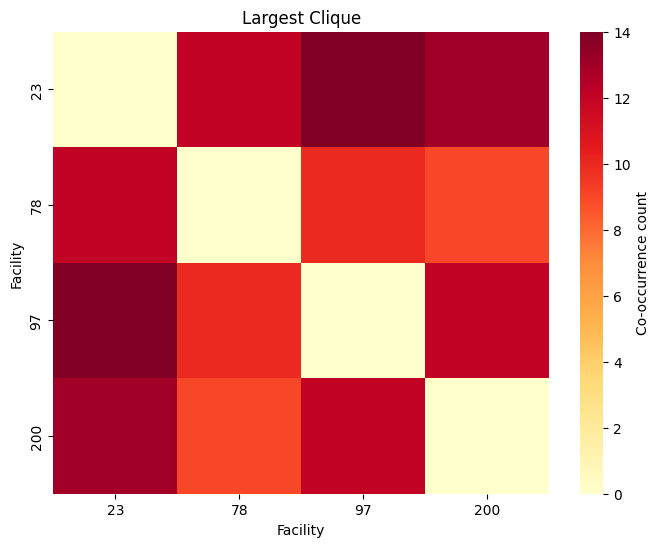

In [21]:
if cliques:
    largest_clique = min(cliques, key=best_clique)

    clique_subgraph = np.zeros(
        (
            len(largest_clique),
            len(largest_clique)
        )
    )

    for i, node_i in enumerate(largest_clique):
        for j, node_j in enumerate(largest_clique):
            clique_subgraph[i, j] = adjacency_matrix[node_i, node_j]

    plt.figure(figsize=(8, 6))

    sns.heatmap(clique_subgraph           ,
                xticklabels=largest_clique,
                yticklabels=largest_clique,
                cmap    ='YlOrRd',
                cbar_kws={'label': 'Co-occurrence count'})

    plt.title (f"Largest Clique")
    plt.xlabel("Facility")
    plt.ylabel("Facility")

    plt.show()

### GREEDY DENSEST SUBGRAPH DETECTION

This section identifies the **densest subgraph** of the facility co-occurrence network using a greedy peeling algorithm.

The method iteratively removes the node with the lowest weighted degree and tracks the subset of nodes that maximizes average internal edge weight (density). Unlike cliques, which require full pairwise connectivity, the densest subgraph captures a strongly interconnected structural core without requiring complete connectivity.

The resulting subgraph represents the most cohesive backbone of the near-optimal solution landscape. It highlights a group of facilities that consistently co-occur with high intensity, revealing a robust structural nucleus of the network.

In [22]:
def densest_subgraph_greedy(adjacency_matrix, min_size=3):
    n = adjacency_matrix.shape[0]

    remaining     = set(range(n))
    best_subgraph = set()
    best_density  = 0

    while len(remaining) >= min_size:
        subgraph_array = adjacency_matrix[
            np.ix_(
                sorted(remaining),
                sorted(remaining)
            )
        ]

        current_weight  = np.sum(subgraph_array) / 2
        current_density = current_weight / len(remaining)

        if current_density > best_density:
            best_subgraph = remaining.copy()
            best_density  = current_density

        min_degree = float('inf')
        min_node   = None

        for node in remaining:
            degree = sum(
                adjacency_matrix[node, j]
                for j in remaining
                if  j != node
            )

            if degree < min_degree:
                min_degree = degree
                min_node   = node

        if min_node is not None:
            remaining.remove(min_node)
        else:
            break

    return best_subgraph, best_density

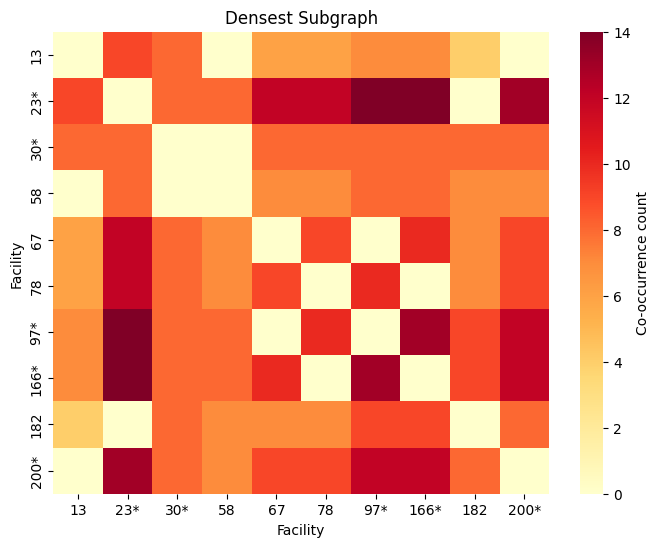

In [23]:
densest_nodes, _ = densest_subgraph_greedy(
    adjacency_matrix, min_size=3
)

densest_nodes_sorted    = sorted(list(densest_nodes))
densest_subgraph_matrix = adjacency_matrix[
    np.ix_(
        densest_nodes_sorted,
        densest_nodes_sorted
    )
]

tick_labels = [
    f"{node}*" if node in best_set else f"{node}"
    for node in densest_nodes_sorted
]


plt.figure(figsize=(8, 6))

sns.heatmap(densest_subgraph_matrix,
            xticklabels=tick_labels,
            yticklabels=tick_labels,
            cmap    ='YlOrRd',
            cbar_kws={'label': 'Co-occurrence count'})

plt.title (f"Densest Subgraph")
plt.xlabel("Facility")
plt.ylabel("Facility")

plt.show()

The two sets (k-core max and densest subgraph) are **highly similar**, which is a strong indication that the co-occurrence graph contains a **well-defined structural core**:

**Highest k-core**  
13, 23, 30, 67, 78, 97, 166, 182, 200, 203

**Densest subgraph**  
13, 23, 30, 58, 67, 78, 97, 166, 182, 200

The nodes shared by both sets are:

**13, 23, 30, 67, 78, 97, 166, 182, 200**

That is, **9 out of 10 nodes coincide**. This suggests that these 9 nodes are the strongest candidates to represent the **core structure** of the solution co-occurrence graph:

- they belong to a region of high global connectivity, as indicated by the k-core analysis;
- at the same time, they form part of a highly cohesive local structure, as indicated by the densest subgraph.

**Differences**:

- **203** appears in the highest k-core, but **not** in the densest subgraph.
- **58** appears in the densest subgraph, but **not** in the highest k-core.

Structural Interpretation:

1. Meaning of belonging to the highest k-core: a node in the highest k-core belongs to a part of the graph in which every node has at least a relatively high degree **within that core**.

Therefore, node **203** likely:
- is well integrated into the core structure;
- has enough connectivity to remain in the k-core decomposition;
- but may have connections that are more distributed rather than concentrated inside the most compact subgroup.

2. Meaning of belonging to the densest subgraph: the densest subgraph aims to maximize the **average connection density** among the nodes in the selected set.

Therefore, node **58** likely:
- participates in a very cohesive subgroup;
- has particularly strong co-occurrence relationships with that specific subset of nodes;
- but may not be globally connected enough to appear among the top k-core nodes.

**Interpretability perspective:**

This result suggests the existence of two possible structural roles. The nodes common to both sets, namely **{13, 23, 30, 67, 78, 97, 166, 182, 200}**, are the most structurally relevant ones. They appear to represent:

- facilities that co-occur very frequently;
- a central block of the solution space;
- potentially essential or highly compatible facilities.

**More global than cohesive 203**

- seems important for maintaining the broader core connectivity;
- but does not necessarily belong to the most compact and cohesive subgroup.

**More cohesive than globally central 58**

- seems strongly embedded in a specific compact cluster;
- but is less central from the perspective of global k-core structure.

**Main Conclusion**

The main conclusion is: there exists a **robust core of 9 facilities** that is simultaneously identified by two different notions of structural importance: **global cohesion through k-core decomposition** and **local compactness through densest subgraph analysis**.

This is an important finding because it shows **consistency across different structural criteria**. From an interpretability perspective, this shared set is a strong candidate to represent:

- the most stable block in the solution space;
- recurrent patterns of facility selection;
- a possible structural basis of high-quality solutions.

> The result indicates the presence of a highly stable facility core in the co-occurrence graph, with strong overlap between the highest k-core and the densest subgraph, while nodes 203 and 58 appear to play distinct structural roles: one more global and the other more locally cohesive.